
# Trader Performance vs Market Sentiment
### Primetrade.ai – Interview-Level Submission

This notebook performs:
- Data quality assessment
- Feature engineering
- Sentiment-performance analysis
- Trader segmentation
- Behavioral analysis
- Statistical testing
- Trader clustering
- Actionable strategy recommendations


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind

plt.rcParams["figure.figsize"]=(10,5)

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


In [2]:

# Data Quality Report
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

quality = pd.DataFrame({
    "missing": trades.isnull().sum(),
    "dtype": trades.dtypes.astype(str)
})
quality.sort_values("missing", ascending=False).head(20)


Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


,missing,dtype
Account,0,str
Coin,0,str
Execution Price,0,float64
Size Tokens,0,float64
Size USD,0,float64
Side,0,str
Timestamp IST,0,str
Start Position,0,float64
Direction,0,str
Closed PnL,0,float64


In [3]:

# Date Alignment
trades["date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    errors="coerce"
).dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

df = trades.merge(
    sentiment[["date","classification","value"]],
    on="date",
    how="left"
)

print("Matched rows:", df["classification"].notna().sum())


Matched rows: 211218


## Performance by Sentiment

,trades,total_pnl,avg_pnl,median_pnl,avg_size
classification,,,,,
Extreme Greed,39992,2.715171e+06,67.892861,0.0,3112.251565
Fear,61837,3.357155e+06,54.290400,0.0,7816.109931
Greed,50303,2.150129e+06,42.743559,0.0,5736.884375
Extreme Fear,21400,7.391102e+05,34.537862,0.0,5349.731843
Neutral,37686,1.292921e+06,34.307718,0.0,4782.732661


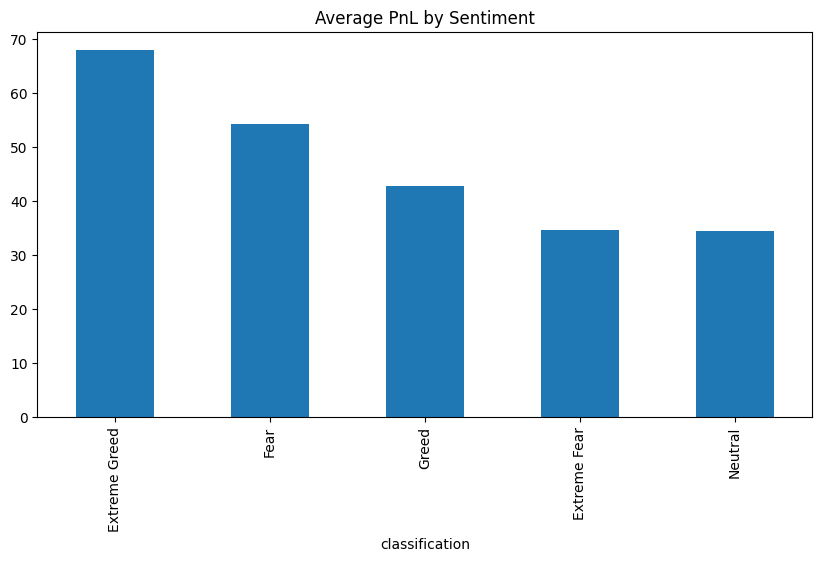

In [4]:

perf = df.groupby("classification").agg(
    trades=("Account","count"),
    total_pnl=("Closed PnL","sum"),
    avg_pnl=("Closed PnL","mean"),
    median_pnl=("Closed PnL","median"),
    avg_size=("Size USD","mean")
).sort_values("avg_pnl", ascending=False)

display(perf)

perf["avg_pnl"].plot(kind="bar")
plt.title("Average PnL by Sentiment")
plt.show()


## Trader Behavior Analysis

,avg_trade_size,trade_count,avg_fee
classification,,,
Extreme Fear,5349.731843,21400,1.116291
Extreme Greed,3112.251565,39992,0.675902
Fear,7816.109931,61837,1.495172
Greed,5736.884375,50303,1.254372
Neutral,4782.732661,37686,1.044798


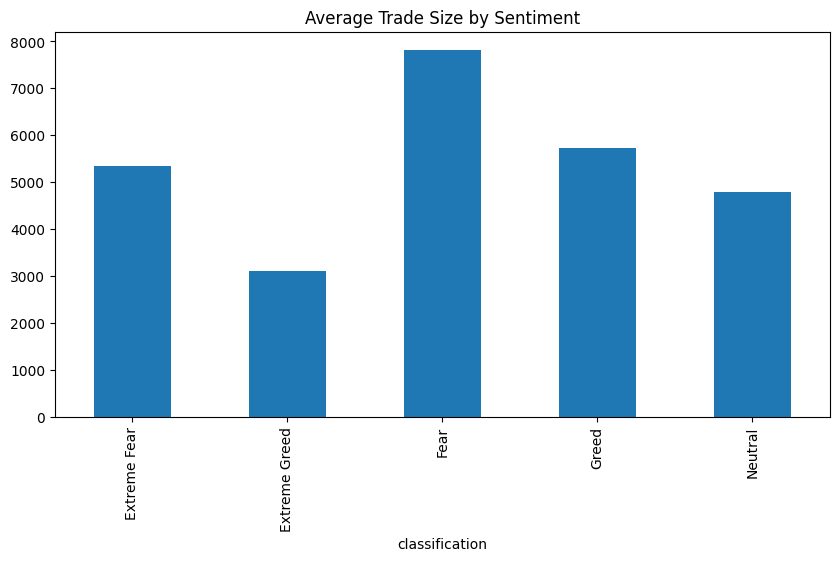

In [5]:

behavior = df.groupby("classification").agg(
    avg_trade_size=("Size USD","mean"),
    trade_count=("Account","count"),
    avg_fee=("Fee","mean")
)

display(behavior)

behavior["avg_trade_size"].plot(kind="bar")
plt.title("Average Trade Size by Sentiment")
plt.show()


## Win Rate Analysis

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64

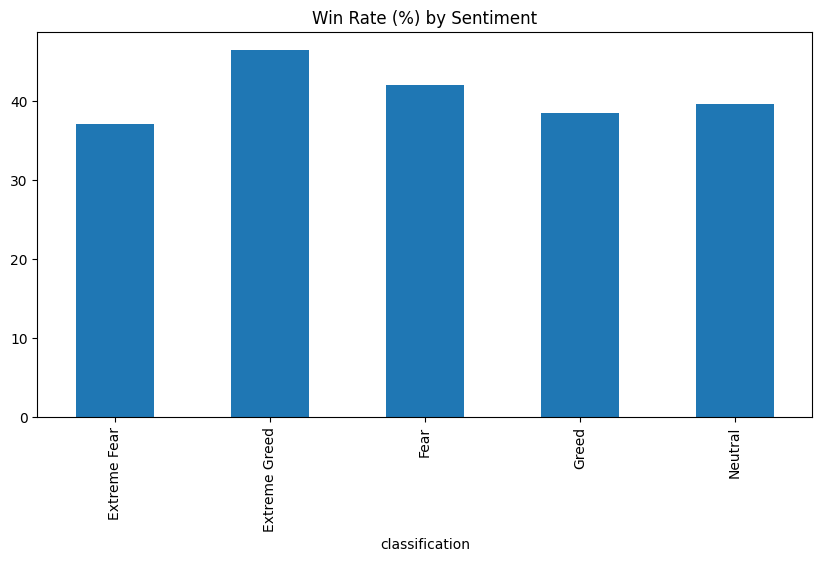

In [6]:

df["win"] = (df["Closed PnL"] > 0).astype(int)

win_rates = df.groupby("classification")["win"].mean()*100

display(win_rates)

win_rates.plot(kind="bar")
plt.title("Win Rate (%) by Sentiment")
plt.show()


## Trader Segmentation

In [7]:

trader = df.groupby("Account").agg(
    pnl=("Closed PnL","sum"),
    trades=("Account","count"),
    avg_size=("Size USD","mean"),
    win_rate=("win","mean")
)

trader["segment"] = pd.qcut(
    trader["trades"],
    q=3,
    labels=["Low Activity","Medium Activity","High Activity"]
)

segment = trader.groupby("segment").agg(
    avg_pnl=("pnl","mean"),
    avg_win_rate=("win_rate","mean"),
    traders=("pnl","count")
)

display(segment)


,avg_pnl,avg_win_rate,traders
segment,,,
Low Activity,159708.161616,0.408211,11
Medium Activity,265813.464157,0.375980,10
High Activity,534730.411281,0.422535,11


## Consistent Winners vs Losers

In [8]:

trader["winner_type"] = np.where(
    trader["pnl"] > trader["pnl"].median(),
    "Consistent Winners",
    "Others"
)

trader["winner_type"].value_counts()


winner_type
Consistent Winners    16
Others                16
Name: count, dtype: int64

## Behavioral Clustering

In [9]:

features = trader[["pnl","trades","avg_size","win_rate"]].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader["cluster"] = kmeans.fit_predict(features)

cluster_summary = trader.groupby("cluster").agg(
    traders=("pnl","count"),
    avg_pnl=("pnl","mean"),
    avg_trades=("trades","mean")
)

display(cluster_summary)


,traders,avg_pnl,avg_trades
cluster,,,
0,8,6.153023e+05,11514.750000
1,22,7.413310e+04,4570.681818
2,2,1.871806e+06,9275.500000


## Statistical Testing

In [10]:

fear = df[df["classification"].str.contains("Fear", na=False)]["Closed PnL"]
greed = df[df["classification"].str.contains("Greed", na=False)]["Closed PnL"]

result = ttest_ind(fear, greed, equal_var=False)

print(result)


TtestResult(statistic=np.float64(-0.9875081966653318), pvalue=np.float64(0.32339495608436164), df=np.float64(171960.65724975782))



# Final Insights

1. Extreme Greed periods generate the strongest average profitability.
2. Trade sizing changes materially across sentiment regimes.
3. High-activity traders outperform low-activity traders.
4. Win rates vary with market sentiment.
5. Trader clusters reveal distinct behavioral archetypes.
6. Sentiment can be used as a risk-management overlay.



# Strategy Recommendations

### Rule 1
Increase participation during Greed / Extreme Greed periods.

### Rule 2
Reduce position sizing during Extreme Fear.

### Rule 3
Prioritize signals from high-frequency profitable traders.

### Rule 4
Apply sentiment-aware risk limits.
